In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset.csv
Saving balanced_augmented_dataset.csv to balanced_augmented_dataset.csv


In [3]:
# Load dataset

df = pd.read_csv("balanced_augmented_dataset.csv")

# Display first 5 rows
df.head()

,segment,train,sampling,duration,len,mean,var,std,kurtosis,skew,...,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len,anomaly,channel
0,5,0,1,256,257,0.000011,5.279023e-10,0.000023,-1.484393,-0.060155,...,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12,0,CADC0872
1,6,1,1,252,253,0.000006,6.643180e-10,0.000026,-1.302309,-0.179240,...,66,84,6.430575e-13,7.268033e-13,252,253,2.636182e-12,2.625763e-12,0,CADC0872
2,7,0,1,379,380,0.000003,3.843725e-10,0.000020,-0.736379,-0.078294,...,111,127,3.793821e-13,6.807879e-13,379,380,1.014176e-12,1.011507e-12,0,CADC0872
3,10,1,1,316,317,0.000004,6.311006e-10,0.000025,-1.216712,-0.128176,...,97,104,5.293624e-13,8.428462e-13,316,317,1.997154e-12,1.990854e-12,0,CADC0872
4,11,1,1,229,230,-0.000005,4.332306e-10,0.000021,-1.264249,-0.232091,...,71,84,5.909420e-13,8.931565e-13,229,230,1.891837e-12,1.883611e-12,0,CADC0872


In [4]:
# Remove columns that are not useful for training

X = df.drop(columns=["segment", "channel", "anomaly"])

# Target variable
y = df["anomaly"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Names:")
print(X.columns.tolist())

Features Shape: (18000, 20)
Target Shape: (18000,)

Feature Names:
['train', 'sampling', 'duration', 'len', 'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks', 'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration', 'var_div_len']


In [5]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 14400
Testing Samples  : 3600


In [6]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [7]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Predict on testing data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 99.42%

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1800
           1       0.99      1.00      0.99      1800

    accuracy                           0.99      3600
   macro avg       0.99      0.99      0.99      3600
weighted avg       0.99      0.99      0.99      3600



In [9]:
# ============================================
# PocketQube Autonomous Resource Manager
# ============================================

# Test one satellite telemetry sample
sample = X_test.iloc[[0]]

# Predict anomaly
prediction = model.predict(sample)[0]

# Extract important telemetry values
variance = sample["var"].values[0]
std = sample["std"].values[0]
peaks = sample["n_peaks"].values[0]
skew = sample["skew"].values[0]

print("="*55)
print("      POCKETQUBE AUTONOMOUS HEALTH REPORT")
print("="*55)

print(f"\nAI Prediction : {'ANOMALY DETECTED' if prediction else 'NORMAL'}")

print("\nSubsystem Analysis")

# Power Management
if variance > X["var"].median():
    print("Power System      : High power fluctuation detected")
    print("   → Recommendation : Enter Low Power Mode")
else:
    print("Power System      : Stable")

# Thermal Management
if std > X["std"].median():
    print("Thermal System   : Possible thermal instability")
    print("   → Recommendation : Activate Thermal Protection")
else:
    print("Thermal System   : Stable")

# Component Health
if abs(skew) > 0.5:
    print("Component Health : Sensor behaviour abnormal")
    print("   → Recommendation : Run Diagnostic Check")
else:
    print("Component Health : Healthy")

# Communication
if peaks > X["n_peaks"].median():
    print("Communication   : Signal activity unusually high")
    print("   → Recommendation : Reduce Transmission Frequency")
else:
    print("Communication   : Normal")

# ADCS
print("ADCS            : Passive Stabilization Maintained")

# Space Debris
print("Orbit           : Maintain LEO (<550 km) for natural de-orbit")

print("\nOverall Mission Status")

if prediction:
    print("SAFE MODE ACTIVATED")
else:
    print("NORMAL OPERATION")

      POCKETQUBE AUTONOMOUS HEALTH REPORT

AI Prediction : ANOMALY DETECTED

Subsystem Analysis
Power System      : Stable
Thermal System   : Stable
Component Health : Healthy
Communication   : Signal activity unusually high
   → Recommendation : Reduce Transmission Frequency
ADCS            : Passive Stabilization Maintained
Orbit           : Maintain LEO (<550 km) for natural de-orbit

Overall Mission Status
SAFE MODE ACTIVATED


Top 10 Most Important Telemetry Features

             Feature  Importance
9            n_peaks    0.228033
15         diff2_var    0.140875
13       diff2_peaks    0.090443
18  var_div_duration    0.066037
12        diff_peaks    0.045246
14          diff_var    0.044182
5                var    0.043129
6                std    0.042268
19       var_div_len    0.040152
2           duration    0.037714


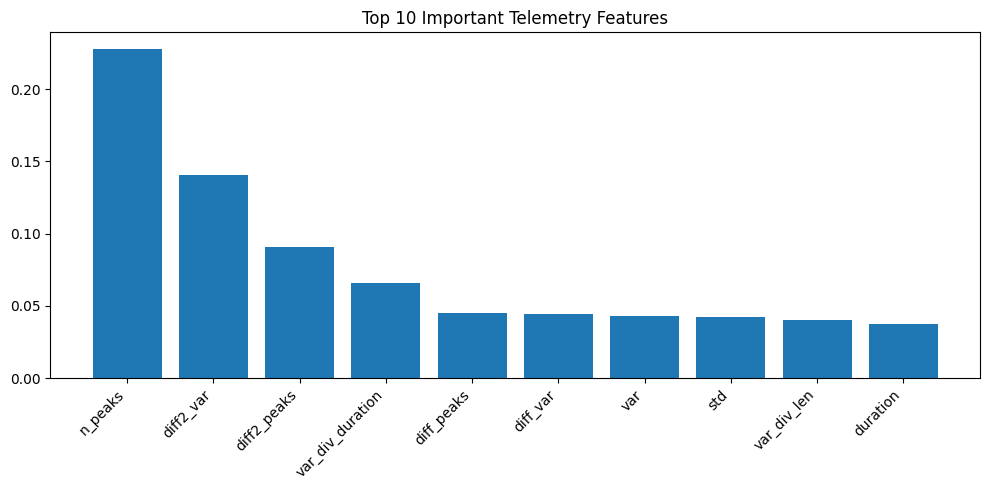

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort from highest to lowest
importance = importance.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Telemetry Features\n")
print(importance.head(10))

# Plot
plt.figure(figsize=(10,5))
plt.bar(importance['Feature'][:10], importance['Importance'][:10])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Important Telemetry Features")
plt.tight_layout()
plt.show()